# Mean value <x> of the biverse (n0 = n1 = 0)

Analytical derivation of the mean value <x> for the ground state (n0=n1=0),
obtained by integrating |Psi|^2 * x over x in [0, inf) term by term (the
diagonal terms <x>_00, <x>_11 and the interference cross term <x>_01).
Compared against the Bohmian trajectory x(tau) from the guidance equation.


In [1]:
import numpy as np
import math
from scipy.integrate import solve_ivp
from scipy.special import gamma, genlaguerre
import matplotlib.pyplot as plt

nu      = 1       # affine parameter
n0      = 0       # quantum number for state 0
n1      = 0       # quantum number for state 1
r       = 2.0     # energy ratio  E1/E0
Dtau    = 50.0    # bounce-time separation  Δτ
rho     = 1.0     # amplitude ratio  ρ
delta   = 0.0     # relative phase  δ

xi0 = 9 * np.pi / 16   # = compute_xi(0, 1), closed-form value for n=0
xi1 = 9 * np.pi / 16

E0, E1 = 1.0, r
qB0, qB1 = xi0 / np.sqrt(E0), xi1 / np.sqrt(E1)
om0, om1 = 2 * E0 / xi0,      2 * E1 / xi1
tB0, tB1 = 0.0,               Dtau

t = np.linspace(-300, 300, 10000)

def q_sc(t, qB, om, tB):
    return qB * np.sqrt(1.0 + om**2 * (t - tB)**2)

def p_sc(t, qB, om, tB):
    dt = t - tB
    return 0.5 * qB * om**2 * dt / np.sqrt(1.0 + om**2 * dt**2)

q0, p0 = q_sc(t, qB0, om0, tB0), p_sc(t, qB0, om0, tB0)
q1, p1 = q_sc(t, qB1, om1, tB1), p_sc(t, qB1, om1, tB1)


In [2]:
# ── Mean value <x>: diagonal terms ──
# <x> = <Psi|x|Psi>, split into the two diagonal ("self") terms <x>_00, <x>_11
# and the interference cross term <x>_01, each obtained by integrating
# x*|psi_a|^2 (or x*psi_0*psi_1*) over x in [0, inf)
K0 = np.sqrt(2) * xi0 / (q0**2)
K1 = np.sqrt(2) * xi1 / (q1**2)

alpha0 = xi0 / (q0**2)
alpha1 = xi1 / (q1**2)

x_00 = 3 * K0**2 * np.sqrt(np.pi) / 8 * alpha0**(-5/2)
x_11 = 3 * K1**2 * np.sqrt(np.pi) / 8 * alpha1**(-5/2)

# ── Cross term <x>_01 ──
A0 = (xi0**2 - (q0*p0)**2) / (xi0**2 + (q0*p0)**2)
B0 = (2*xi0*q0*p0) / (xi0**2 + (q0*p0)**2)
A1 = (xi1**2 - (q1*p1)**2) / (xi1**2 + (q1*p1)**2)
B1 = (2*xi1*q1*p1) / (xi1**2 + (q1*p1)**2)

a = A1*A0 + B1*B0
b = A1*B0 - A0*B1
omega = (p1/q1 - p0/q0) / 2
alpha = (alpha0 + alpha1) / 2

re_I = (alpha**2 + omega**2)**(-5/4) * np.cos(5/2 * np.arctan2(-omega, alpha))
im_I = -(alpha**2 + omega**2)**(-5/4) * np.sin(5/2 * np.arctan2(-omega, alpha))

x_10_01 = K0*K1 * 3*np.sqrt(np.pi)/8 * (a*re_I - b*im_I)

# ── Normalization and total mean value ──
f = alpha**2 - omega**2
g = -2*alpha*omega
c = f / (f**2 + g**2)
d = -g / (f**2 + g**2)
Omega = a*c - b*d
N = xi0*xi1 / (q0*q1)**2
re_01 = N * Omega

norm = (2 + 2*re_01)**(-1/2)
x_mean = (x_00 + x_11 + 2*x_10_01) * norm**2


In [3]:
# ── Bohmian trajectory x(tau) via the guidance equation ──
def get_alpha_q(tau, qB, om, tB, xi_val):
    # alpha (α) is the complex Gaussian spread parameter of the wavefunction
    # branch: Re(α) = xi sets its width via q, Im(α) = -q*p carries the phase curvature
    q = q_sc(tau, qB, om, tB)
    p = p_sc(tau, qB, om, tB)
    return xi_val - 1j*q*p, q

L_n0, L_n0_m1 = genlaguerre(n0, nu), genlaguerre(n0 - 1, nu + 1) if n0 > 0 else lambda y: np.zeros_like(y)
L_n1, L_n1_m1 = genlaguerre(n1, nu), genlaguerre(n1 - 1, nu + 1) if n1 > 0 else lambda y: np.zeros_like(y)

coeff_N0 = math.sqrt(math.factorial(n0) / gamma(nu + n0 + 1))
coeff_N1 = math.sqrt(math.factorial(n1) / gamma(nu + n1 + 1))
constant_ratio = (coeff_N1 / coeff_N0) * ((xi1 / xi0)**((nu + 1) / 2.0))

def guidance_rhs(tau, state):
    # Bohmian velocity field dx/dtau = 2 Im[d(ln Psi)/dx] for the biverse
    # superposition Psi = psi_0 + w * psi_1
    x = state[0]
    al0, q0 = get_alpha_q(tau, qB0, om0, tB0, xi0)
    al1, q1 = get_alpha_q(tau, qB1, om1, tB1, xi1)

    y0, y1 = xi0 * (x**2) / (q0**2), xi1 * (x**2) / (q1**2)
    eps = 1e-300  # avoids a 0/0 division right at the nodes of the Laguerre polynomials
    val_L0, val_L1 = L_n0(y0) + eps, L_n1(y1) + eps

    term_L0 = 2.0 * xi0 * (x / q0**2) * L_n0_m1(y0) / val_L0 if n0 > 0 else 0.0
    term_L1 = 2.0 * xi1 * (x / q1**2) * L_n1_m1(y1) / val_L1 if n1 > 0 else 0.0

    f0 = (nu + 0.5)/x - term_L0 - al0 * x / q0**2
    f1 = (nu + 0.5)/x - term_L1 - al1 * x / q1**2

    power_phase0, power_phase1 = (2*n0 + nu + 1)/2.0, (2*n1 + nu + 1)/2.0
    ratio_q = (q0/q1)**(nu + 1)
    ratio_alpha = (al1 / np.conj(al1))**power_phase1 / (al0 / np.conj(al0))**power_phase0
    poly_ratio = val_L1 / val_L0
    exp_arg = 0.5 * x**2 * (al0/q0**2 - al1/q1**2)

    # w = psi_1/psi_0, weighted by the biverse amplitude ratio rho and phase delta
    w = rho * np.exp(-1j*delta) * constant_ratio * ratio_q * ratio_alpha * poly_ratio * np.exp(exp_arg)
    return [2.0 * np.imag((f0 + w*f1) / (1.0 + w))]

tau_i, tau_f = -300.0, 300.0
x_i = q_sc(tau_i, qB0, om0, tB0)
tau_traj = np.linspace(tau_i, tau_f, 2500)

# Radau (implicit solver): the ODE becomes stiff close to the bounces
sol = solve_ivp(guidance_rhs, (tau_i, tau_f), [x_i], method='Radau',
                 t_eval=tau_traj, rtol=1e-9, atol=1e-11)
x_traj = sol.y[0]


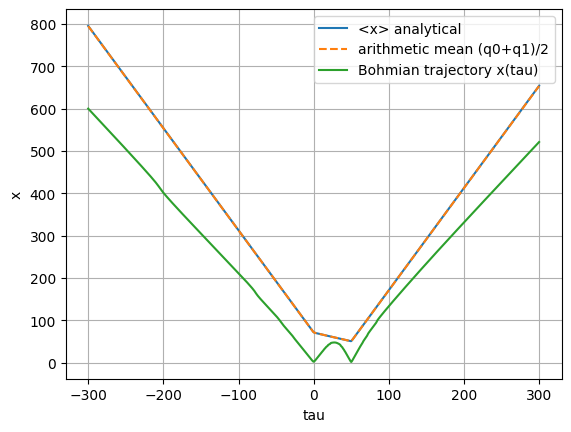

In [4]:
plt.figure()
plt.plot(t, x_mean, label='<x> analytical')
plt.plot(t, (q0 + q1)/2, '--', label='arithmetic mean (q0+q1)/2')
plt.plot(sol.t, x_traj, label='Bohmian trajectory x(tau)')
plt.xlabel('tau')
plt.ylabel('x')
plt.grid()
plt.legend()
plt.savefig('x_mean_and_trajectory.png', dpi=300)
plt.show()
